## Appearance-Based Model (Option B) — Optimal Single-Model Pipeline

Pipeline: **multi-scale HOG + HSV histogram → standardize (train-only) → PCA → LinearSVC**.

Derived from systematic experiments in notebook `02b` (mixture-of-experts ablation). The strongest
single expert used two HOG scales (fine `ppc=(8,8)` and coarse `ppc=(16,16)`) concatenated with an
HSV color histogram, which consistently beat single-scale greyscale HOG by ~0.5 pp. Internal
metrics use a stratified 80/20 split; the best configuration is **retrained on all labeled images**
before Kaggle submission.

Key design choices vs the old Option B:
- **Color images** (RGB, 128×128) instead of greyscale — required for HSV features
- **Two HOG scales** concatenated: fine `ppc=(8,8)` + coarse `ppc=(16,16)`, both with 9 orientations and `cpb=(2,2)`
- **HSV histogram**: 12 bins per channel (H, S, V) → 36 extra features
- **PCA = 300**, **C = 0.1** (best from 02b grid search)


In [5]:
from pathlib import Path
import sys

# Add repository root so src imports work when running from notebooks/.
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.config import (
    PART1_KAGGLE_DIR,
    PART2_IMAGES_DIR,
    PART2_ANNOTATIONS_DIR,
    validate_data_layout,
)

validate_data_layout()

print("Data paths validated:")
print(f"- Part 1: {PART1_KAGGLE_DIR}")
print(f"- Part 2 Images: {PART2_IMAGES_DIR}")
print(f"- Part 2 Annotations: {PART2_ANNOTATIONS_DIR}")

Data paths validated:
- Part 1: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/data/part1/data/kaggle
- Part 2 Images: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/data/part2/Stanford Dog Dataset/Images
- Part 2 Annotations: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/data/part2/Stanford Dog Dataset/Annotation


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from skimage.feature import hog
from tqdm import tqdm

from src.config import OUTPUTS_DIR, IMG_SIZE_CLASSICAL
from src.utils import (
    apply_pca,
    generate_submission_csv,
    load_labeled_images,
    load_test_images,
    split_data,
    standardize_features,
)
from src.evaluation import compute_metrics, compute_confusion_matrix, compare_models
from src.visualization import (
    plot_confusion_matrix,
    plot_sample_predictions,
    plot_model_comparison,
)

In [7]:
# Load COLOR images (needed for HSV features)
IMG_SIZE_OPT_B = IMG_SIZE_CLASSICAL  # (128, 128)

X, y, train_ids = load_labeled_images(
    img_size=IMG_SIZE_OPT_B,
    grayscale=False,   # <-- RGB color
    return_ids=True,
)

print(f"Loaded images shape: {X.shape}")
print(f"Loaded labels shape: {y.shape}")
print(f"Example IDs: {train_ids[:3]}")
print(f"Class distribution: {np.bincount(y)}  (cat, dog)")

Loading dogs: 100%|██████████| 9979/9979 [00:07<00:00, 1423.23it/s]


Loaded images shape: (20000, 128, 128, 3)
Loaded labels shape: (20000,)
Example IDs: ['cat.0' 'cat.1' 'cat.10']
Class distribution: [10021  9979]  (cat, dog)


In [8]:
# Split labeled data into train and internal test sets (stratified 80/20)
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Test set:  {X_test.shape}, {y_test.shape}")

Train set: (16000, 128, 128, 3), (16000,)
Test set:  (4000, 128, 128, 3), (4000,)


In [9]:
# ---------------------------------------------------------------------------
# Feature extraction helpers
# ---------------------------------------------------------------------------

def _to_gray_uint8(img: np.ndarray) -> np.ndarray:
    """Convert a float32 [0,1] RGB image to uint8 grayscale."""
    if img.ndim == 3 and img.shape[2] == 3:
        gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
    else:
        gray = img
    return (gray * 255).astype(np.uint8)


def extract_hsv_histogram(
    images: np.ndarray,
    bins: int = 12,
) -> np.ndarray:
    """Compute normalized HSV histogram features (bins per channel) for a batch.

    Returns
    -------
    features : np.ndarray, shape (n_samples, 3 * bins)
    """
    feats = []
    for img in tqdm(images, desc="Extracting HSV histogram"):
        # img is float32 [0,1] RGB
        rgb_u8 = (img * 255).astype(np.uint8)
        hsv = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2HSV)
        hist_h, _ = np.histogram(hsv[..., 0], bins=bins, range=(0, 180), density=True)
        hist_s, _ = np.histogram(hsv[..., 1], bins=bins, range=(0, 256), density=True)
        hist_v, _ = np.histogram(hsv[..., 2], bins=bins, range=(0, 256), density=True)
        feats.append(np.concatenate([hist_h, hist_s, hist_v]))
    return np.array(feats, dtype=np.float32)


def extract_multiscale_hog(
    images: np.ndarray,
    orientations: int = 9,
    cells_per_block: tuple = (2, 2),
    scales_ppc: list = [(8, 8), (16, 16)],
) -> np.ndarray:
    """Extract HOG at multiple pixel-per-cell scales and concatenate.

    Parameters
    ----------
    images : np.ndarray, float32 [0,1], shape (N, H, W) or (N, H, W, 3)
    scales_ppc : list of (ppc_h, ppc_w) tuples
        Each entry defines one HOG scale.

    Returns
    -------
    features : np.ndarray, shape (n_samples, total_hog_dim)
    """
    all_feats = []
    for img in tqdm(images, desc="Extracting multi-scale HOG"):
        gray = _to_gray_uint8(img)
        parts = []
        for ppc in scales_ppc:
            fd = hog(
                gray,
                orientations=orientations,
                pixels_per_cell=ppc,
                cells_per_block=cells_per_block,
                feature_vector=True,
            )
            parts.append(fd)
        all_feats.append(np.concatenate(parts))
    return np.array(all_feats, dtype=np.float32)


def extract_combined_features(
    images: np.ndarray,
    hog_orientations: int = 9,
    hog_cells_per_block: tuple = (2, 2),
    hog_scales_ppc: list = [(8, 8), (16, 16)],
    hsv_bins: int = 12,
) -> np.ndarray:
    """Extract multi-scale HOG + HSV histogram and concatenate into one vector."""
    hog_feats = extract_multiscale_hog(
        images,
        orientations=hog_orientations,
        cells_per_block=hog_cells_per_block,
        scales_ppc=hog_scales_ppc,
    )
    hsv_feats = extract_hsv_histogram(images, bins=hsv_bins)
    return np.concatenate([hog_feats, hsv_feats], axis=1)


print("Feature extraction helpers defined.")
print("Pipeline: multi-scale HOG (ppc=8 + ppc=16) + HSV histogram (12 bins/channel)")

Feature extraction helpers defined.
Pipeline: multi-scale HOG (ppc=8 + ppc=16) + HSV histogram (12 bins/channel)


In [10]:
# ---------------------------------------------------------------------------
# Baseline: raw-pixel PCA + LogisticRegression (for report comparison)
# ---------------------------------------------------------------------------

baseline_results = {}

for n_components in [100, 200]:
    X_train_pca, X_test_pca, _ = apply_pca(X_train, X_test, n_components=n_components)
    baseline = LogisticRegression(max_iter=1000, random_state=42)
    baseline.fit(X_train_pca, y_train)
    y_pred_b = baseline.predict(X_test_pca)
    metrics_b = compute_metrics(y_test, y_pred_b)
    name_b = f"baseline PCA-{n_components}+LogReg"
    baseline_results[name_b] = metrics_b
    print(f"{name_b} -> {metrics_b}")

baseline PCA-100+LogReg -> {'accuracy': 0.59275, 'precision': 0.5942475603492553, 'recall': 0.5796593186372746, 'f1': 0.5868627948262745}
baseline PCA-200+LogReg -> {'accuracy': 0.6175, 'precision': 0.6188775510204082, 'recall': 0.6077154308617234, 'f1': 0.6132457027300303}


In [11]:
# ---------------------------------------------------------------------------
# Extract optimal feature set from train + test splits
# Hyperparameters fixed based on 02b ablation results:
#   HOG: 9 orientations, ppc=(8,8) + ppc=(16,16), cpb=(2,2)
#   HSV: 12 bins per channel
# ---------------------------------------------------------------------------

HOG_ORIENTATIONS     = 9
HOG_CELLS_PER_BLOCK  = (2, 2)
HOG_SCALES_PPC       = [(8, 8), (16, 16)]
HSV_BINS             = 12

print("Extracting features for train split...")
X_train_feats = extract_combined_features(
    X_train,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
)

print("Extracting features for test split...")
X_test_feats = extract_combined_features(
    X_test,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
)

print(f"\nRaw feature dimensionality: {X_train_feats.shape[1]}")
print(f"  (multi-scale HOG + {3 * HSV_BINS} HSV histogram features)")

# Standardize (fit on train only)
X_train_s, X_test_s, feat_scaler = standardize_features(X_train_feats, X_test_feats)
print("Features standardized.")

Extracting features for train split...


Extracting HSV histogram: 100%|██████████| 16000/16000 [00:29<00:00, 549.85it/s]


Extracting features for test split...


Extracting HSV histogram: 100%|██████████| 4000/4000 [00:02<00:00, 1718.52it/s]



Raw feature dimensionality: 9900
  (multi-scale HOG + 36 HSV histogram features)
Features standardized.


In [12]:
# ---------------------------------------------------------------------------
# Grid search: PCA components × SVM C  (focused around 02b best)
# ---------------------------------------------------------------------------

pca_dims = [200, 300, 400, 500]
c_values = [0.01, 0.1, 1.0]

results = {}
for k, v in baseline_results.items():
    results[k] = v

best_accuracy  = -1.0
best_n_components = None
best_C         = None
best_pca       = None
best_svm       = None
best_y_pred    = None

for n_components in pca_dims:
    pca = PCA(n_components=n_components, random_state=42)
    X_tr_pca = pca.fit_transform(X_train_s)
    X_te_pca = pca.transform(X_test_s)

    for C in c_values:
        svm = LinearSVC(C=C, max_iter=10000, dual=False, random_state=42)
        svm.fit(X_tr_pca, y_train)
        y_pred = svm.predict(X_te_pca)
        metrics = compute_metrics(y_test, y_pred)
        name = f"MultiHOG+HSV+PCA-{n_components}+LinearSVC-C={C}"
        results[name] = metrics
        print(f"{name} -> {metrics}")

        if metrics["accuracy"] > best_accuracy:
            best_accuracy     = metrics["accuracy"]
            best_n_components = n_components
            best_C            = C
            best_pca          = pca
            best_svm          = svm
            best_y_pred       = y_pred

print()
print(
    f"Best Option B (multi-scale HOG + HSV): "
    f"PCA n={best_n_components}, C={best_C}, accuracy={best_accuracy:.4f}"
)

MultiHOG+HSV+PCA-200+LinearSVC-C=0.01 -> {'accuracy': 0.735, 'precision': 0.7333000997008973, 'recall': 0.7369739478957916, 'f1': 0.7351324337831084}
MultiHOG+HSV+PCA-200+LinearSVC-C=0.1 -> {'accuracy': 0.735, 'precision': 0.7333000997008973, 'recall': 0.7369739478957916, 'f1': 0.7351324337831084}
MultiHOG+HSV+PCA-200+LinearSVC-C=1.0 -> {'accuracy': 0.735, 'precision': 0.7333000997008973, 'recall': 0.7369739478957916, 'f1': 0.7351324337831084}
MultiHOG+HSV+PCA-300+LinearSVC-C=0.01 -> {'accuracy': 0.74525, 'precision': 0.7421913733267228, 'recall': 0.75, 'f1': 0.7460752554198854}
MultiHOG+HSV+PCA-300+LinearSVC-C=0.1 -> {'accuracy': 0.74525, 'precision': 0.7421913733267228, 'recall': 0.75, 'f1': 0.7460752554198854}
MultiHOG+HSV+PCA-300+LinearSVC-C=1.0 -> {'accuracy': 0.74525, 'precision': 0.7421913733267228, 'recall': 0.75, 'f1': 0.7460752554198854}
MultiHOG+HSV+PCA-400+LinearSVC-C=0.01 -> {'accuracy': 0.74825, 'precision': 0.7449232293214463, 'recall': 0.7535070140280561, 'f1': 0.749190

In [13]:
# Compare all configurations in a metrics table
comparison_df = compare_models(results)
comparison_df

,accuracy,precision,recall,f1
model,,,,
MultiHOG+HSV+PCA-500+LinearSVC-C=0.01,0.75050,0.746055,0.758016,0.751988
MultiHOG+HSV+PCA-500+LinearSVC-C=0.1,0.75025,0.745688,0.758016,0.751801
MultiHOG+HSV+PCA-500+LinearSVC-C=1.0,0.75025,0.745688,0.758016,0.751801
MultiHOG+HSV+PCA-400+LinearSVC-C=0.01,0.74825,0.744923,0.753507,0.749191
MultiHOG+HSV+PCA-400+LinearSVC-C=0.1,0.74825,0.744923,0.753507,0.749191
MultiHOG+HSV+PCA-400+LinearSVC-C=1.0,0.74825,0.744923,0.753507,0.749191
MultiHOG+HSV+PCA-300+LinearSVC-C=0.01,0.74525,0.742191,0.750000,0.746075
MultiHOG+HSV+PCA-300+LinearSVC-C=0.1,0.74525,0.742191,0.750000,0.746075
MultiHOG+HSV+PCA-300+LinearSVC-C=1.0,0.74525,0.742191,0.750000,0.746075


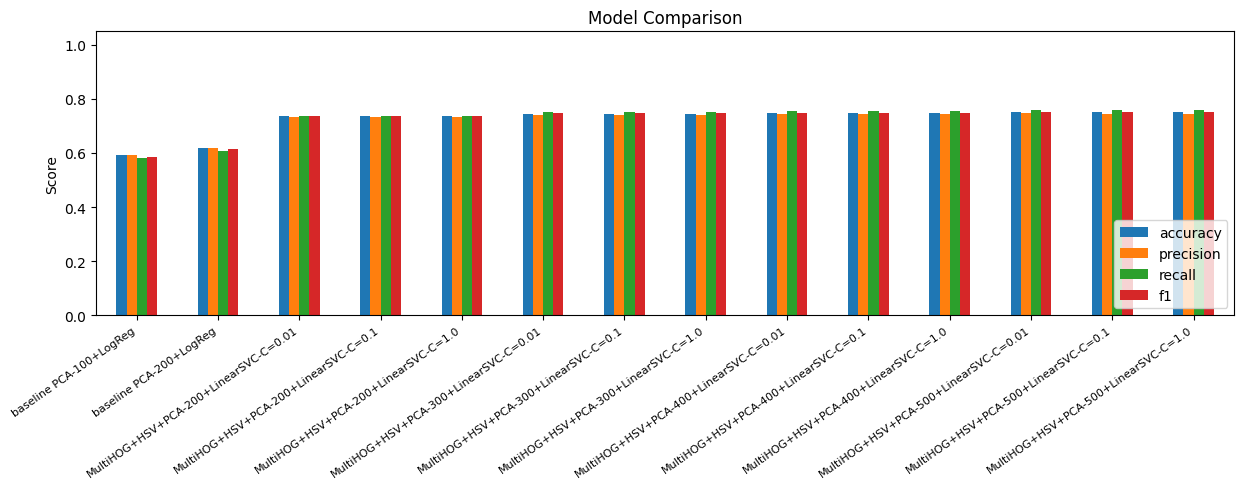

In [14]:
# Plot grouped metric comparison across all configurations
plot_model_comparison(results)

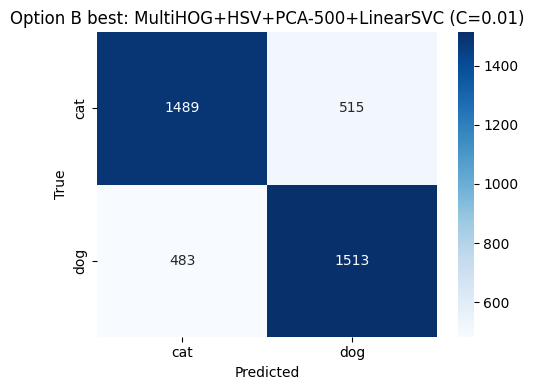

In [15]:
# Compute and display confusion matrix for the best model
best_cm = compute_confusion_matrix(y_test, best_y_pred)
plot_confusion_matrix(
    best_cm,
    title=(
        f"Option B best: MultiHOG+HSV+PCA-{best_n_components}"
        f"+LinearSVC (C={best_C})"
    ),
)

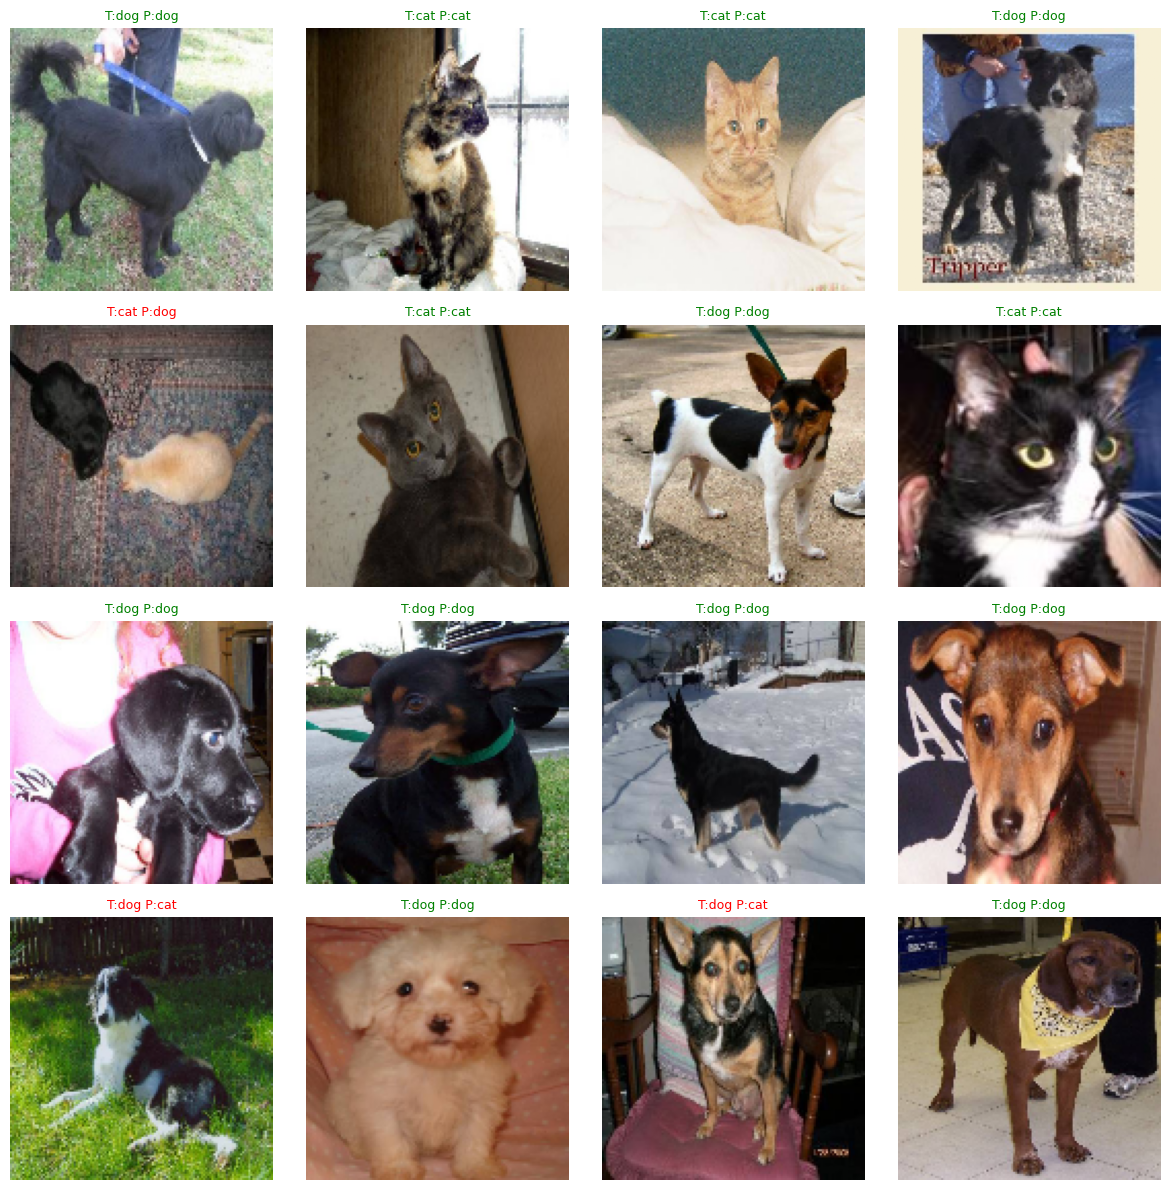

In [16]:
# Show sample predictions from the internal test split
plot_sample_predictions(
    images=X_test,
    y_true=y_test,
    y_pred=best_y_pred,
    n=16,
)

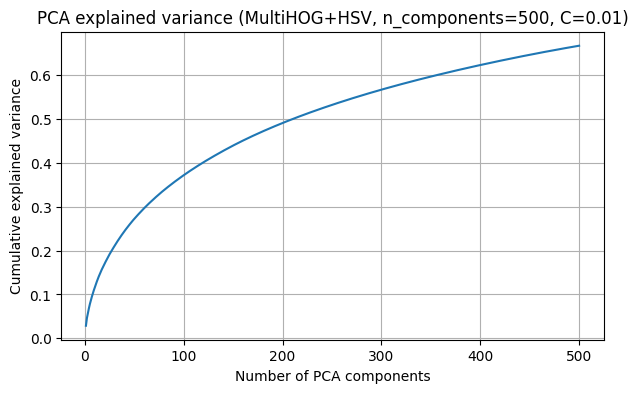

Variance explained by 500 components: 0.667


In [17]:
# Plot cumulative explained variance for the selected PCA model
cumulative_ev = np.cumsum(best_pca.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_ev) + 1), cumulative_ev)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title(
    f"PCA explained variance (MultiHOG+HSV, "
    f"n_components={best_n_components}, C={best_C})"
)
plt.grid(True)
plt.show()

print(f"Variance explained by {best_n_components} components: {cumulative_ev[-1]:.3f}")

In [18]:
# ---------------------------------------------------------------------------
# Retrain best pipeline on ALL labeled data, then generate Kaggle submission
# ---------------------------------------------------------------------------

print("Extracting features for full training set...")
X_all_feats = extract_combined_features(
    X,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
)

X_all_s, _, scaler_final = standardize_features(X_all_feats, X_all_feats)

pca_final = PCA(n_components=best_n_components, random_state=42)
X_all_pca = pca_final.fit_transform(X_all_s)

svm_final = LinearSVC(C=best_C, max_iter=10000, dual=False, random_state=42)
svm_final.fit(X_all_pca, y)
print("Final model trained on all labeled data.")

# Load and transform Kaggle test images
print("Loading Kaggle test images...")
X_kaggle_test, kaggle_ids = load_test_images(
    img_size=IMG_SIZE_OPT_B,
    grayscale=False,
)

print("Extracting features for Kaggle test set...")
X_kaggle_feats = extract_combined_features(
    X_kaggle_test,
    hog_orientations=HOG_ORIENTATIONS,
    hog_cells_per_block=HOG_CELLS_PER_BLOCK,
    hog_scales_ppc=HOG_SCALES_PPC,
    hsv_bins=HSV_BINS,
)

X_kaggle_s   = scaler_final.transform(X_kaggle_feats)
X_kaggle_pca = pca_final.transform(X_kaggle_s)

kaggle_pred   = svm_final.predict(X_kaggle_pca)
kaggle_scores = svm_final.decision_function(X_kaggle_pca)
kaggle_pred_proba = expit(kaggle_scores)  # Platt-style sigmoid of SVM scores

submission_path = (
    OUTPUTS_DIR / "submissions"
    / "optionB_multihog_hsv_pca_linearsvc_submission.csv"
)
submission_path = generate_submission_csv(kaggle_ids, kaggle_pred, submission_path)

debug_path = (
    OUTPUTS_DIR / "tests"
    / "optionB_multihog_hsv_pca_linearsvc_submission_proba.csv"
)
debug_path = generate_submission_csv(kaggle_ids, kaggle_pred_proba, debug_path)

print(f"Submission saved to: {submission_path}")
print(f"Debug (sigmoid of SVM scores) saved to: {debug_path}")

Extracting features for full training set...


Extracting HSV histogram: 100%|██████████| 20000/20000 [00:43<00:00, 464.45it/s]


Final model trained on all labeled data.
Loading Kaggle test images...


Loading test images: 100%|██████████| 5000/5000 [00:04<00:00, 1028.67it/s]


Extracting features for Kaggle test set...


Extracting HSV histogram: 100%|██████████| 5000/5000 [00:02<00:00, 2029.84it/s]


Submission saved to: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/outputs/submissions/optionB_multihog_hsv_pca_linearsvc_submission.csv
Debug (sigmoid of SVM scores) saved to: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/outputs/tests/optionB_multihog_hsv_pca_linearsvc_submission_proba.csv
